# Custom Neural Network for Regression: California Housing Data
**Elements of Artificial Intelligence, AGH 2026**

## Table of Contents
1. [Introduction](#1-introduction)
2. [Methodology & Constraints](#2-methodology--constraints)
3. [Setup & Data Engineering](#3-setup--data-engineering)
4. [Custom Neural Network Architecture](#4-custom-neural-network-architecture)
5. [Hyperparameter Optimization (8 Experiments)](#5-hyperparameter-optimization)
6. [Results & Discussion](#6-results--discussion)

---

## 1. Introduction
### Research Goal
The primary objective of this section is to design, implement, and evaluate a Multilayer Perceptron (MLP) Neural Network applied to a regression problem. While modern frameworks like TensorFlow or PyTorch allow for rapid model deployment, this project takes a fundamental approach: **building the entire neural network architecture from scratch using fundamental linear algebra.**

We will utilize the modified California Housing Dataset to predict the median house value (`Median_House_Value`) based on 12 distinct geographic and demographic features. 

## 2. Methodology & Constraints
Unlike traditional Machine Learning models (like Random Forests or Gradient Boosting explored in the previous sections), training Neural Networks requires a rigorous mathematical foundation. 

**Project Constraints:**
* **No High-Level Deep Learning Libraries:** The core engine of the network (forward pass, backpropagation, gradient descent, and weight updates) is implemented entirely in raw Python and `numpy`.
* **Standardization:** Neural networks are highly sensitive to unscaled data. Features with large absolute values (e.g., population) can easily dominate the loss function calculation, leading to vanishing or exploding gradients. Thus, manual Z-score standardization is applied.
* **Evaluation Metric:** The performance is measured primarily using Mean Absolute Error (MAE) expressed in real-world dollars, providing an intuitive understanding of the model's accuracy.

## 3. Setup & Data Engineering
In alignment with the exploratory data analysis (EDA) conducted in the Machine Learning section of this report, we apply the exact same feature engineering principles to ensure our Neural Network is evaluated on identical grounds:
1. **Removing the $500k Ceiling:** Capped outlier values are dropped to prevent the model from learning artificial market ceilings.
2. **Feature Creation:** Absolute counts (like total rooms) are converted into relative ratios (e.g., `Rooms_per_Household`).
3. **Manual Scaling:** We apply Z-score standardization mathematically without relying on `sklearn.preprocessing`, adhering strictly to the project's constraint of building foundational elements from scratch.

## 3.1 Libraries

In [2]:
import pandas as pd
import numpy as np
import random
import csv
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## 3.2 Loading the Data

In [ ]:

df = pd.read_csv("California_Houses.csv")

#Removing broken data ( fake outliers)
df_clean = df[df['Median_House_Value'] < 500001].copy()

# Future Engineering - making new features based on existing ones
df_clean['Rooms_per_Household'] = df_clean['Tot_Rooms'] / df_clean['Households']
df_clean['Bedrooms_per_Room'] = df_clean['Tot_Bedrooms'] / df_clean['Tot_Rooms']
df_clean['Population_per_Household'] = df_clean['Population'] / df_clean['Households']

# Removing old useless features
columns_to_drop = ['Tot_Rooms', 'Tot_Bedrooms', 'Population', 'Households']
df_clean = df_clean.drop(columns=columns_to_drop)

# Scalling for better training results ( too big values can cause issues with training)
y = (df_clean['Median_House_Value'] / 100000.0).values
X = df_clean.drop(columns=['Median_House_Value']).values

## 3.3 Scalling the Data

In [ ]:
# Scalling features using standardization (Z-score normalization)
X_mean = np.mean(X, axis=0) 
X_std = np.std(X, axis=0) 

# Can't devide by zero
X_std[X_std == 0] = 1e-8 
X_scaled = (X - X_mean) / X_std

## 3.4 Grouping the data into training and testing groups.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=67)

## 3.5 Preparing data tuples for the custom neural network

In [ ]:
training_data = [(x.reshape(-1, 1), np.array([[y_val]])) for x, y_val in zip(X_train, y_train)]
test_data = [(x.reshape(-1, 1), np.array([[y_val]])) for x, y_val in zip(X_test, y_test)]
# reshaping to column vectors for better compatibility with our network
print(f"Dane gotowe! Treningowe: {len(training_data)}, Testowe: {len(test_data)}")
print(f"Kształt wejścia: {training_data[0][0].shape}, Kształt wyjścia: {training_data[0][1].shape}")

Dane gotowe! Treningowe: 15740, Testowe: 3935
Kształt wejścia: (12, 1), Kształt wyjścia: (1, 1)


## 3.6 Mathematical tools

In [ ]:
def sigmoid(z):
    """Funkcja aktywacji dla warstw ukrytych."""
    # np.clip stops overflow by limiting the range of z
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    """Pochodna funkcji sigmoid."""
    return sigmoid(z) * (1 - sigmoid(z))

class MeanSquaredError:
    @staticmethod
    def fn(a, y):
        """Zwraca błąd średniokwadratowy MSE."""
        return 0.5 * np.linalg.norm(a - y)**2

    @staticmethod
    def delta(a, y):
        """
        Zwraca błąd (deltę) dla warstwy WYJŚCIOWEJ LINIOWEJ.
        Dla funkcji liniowej f(z) = z, pochodna to 1.
        Zatem delta = pochodna_kosztu * 1 = (a - y)
        """
        return (a - y)

## 4. Custom Neural Network Architecture
To solve the regression problem, we engineered a custom, object-oriented `RegressionNetwork` class. The architecture diverges significantly from a classification network in two critical areas:

### 4.1. The Output Layer (Linear Activation)
While hidden layers utilize the non-linear Sigmoid function $\sigma(z) = \frac{1}{1 + e^{-z}}$ to capture complex relationships within the housing market, the final output layer **must not** use an activation function. Since we are predicting a continuous monetary value, the final neuron performs a simple linear combination: $a = w \cdot x + b$.

### 4.2. The Cost Function (MSE)
To evaluate the network's performance during training, we utilize the Mean Squared Error (MSE) cost function: 
$$MSE = \frac{1}{2n} \sum_{x} \|y(x) - a^L(x)\|^2$$
For the backpropagation algorithm, the error (delta) of the linear output layer simplifies elegantly to the derivative of the cost function: $\delta^L = (a^L - y)$.

### The Training Algorithm: Step-by-Step Execution
To effectively map the complex, non-linear relationships within the California real estate market, our custom Multilayer Perceptron (MLP) learns through a rigorous mathematical process. The training loop consists of five fundamental phases:

* **1. Initialization (Xavier/He Approach):** The network dynamically constructs weight matrices and bias vectors based on the defined layer sizes (e.g., 12 inputs, 20 hidden neurons, 1 output). To prevent the vanishing or exploding gradient problem right at the start, weights are initialized using random values from a standard normal distribution scaled by $\frac{1}{\sqrt{x}}$ (where $x$ is the number of inputs to the node).

* **2. Forward Propagation (Feedforward):** Input features are passed through the network layer by layer. For the hidden layers, the dot product of inputs and weights (plus biases) is passed through a non-linear **Sigmoid activation function**. Crucially, the final output layer bypasses the activation function, utilizing a pure linear transformation to output a continuous, unconstrained dollar value.

* **3. Error Evaluation (Loss Computation):** Once the network outputs a predicted price, it is immediately compared to the actual market value from the dataset. The algorithm calculates the residual error ($\delta$) utilizing the derivative of the **Mean Squared Error (MSE)** cost function.

* **4. Backpropagation (Gradient Calculation):** This is the core mathematical engine of the network. The algorithm propagates the output error backward through the network. By applying the chain rule of calculus and utilizing the derivative of the Sigmoid function, it calculates the precise gradient for every single weight and bias, effectively determining how much each neuron contributed to the prediction error.

* **5. Optimization via Mini-Batch SGD:** Instead of updating the weights after every single house (which is chaotic) or after evaluating the entire dataset (which is computationally expensive), the network utilizes **Mini-Batch Stochastic Gradient Descent**. It processes small, randomized batches of data (e.g., 10 properties at a time), averages the computed gradients, and adjusts the network's parameters by taking a step determined by the Learning Rate ($\eta$).

In [ ]:
class RegressionNetwork:
    def __init__(self, sizes):
        self.num_layers = len(sizes) 
        self.sizes = sizes #[12,20,1]
        self.cost = MeanSquaredError #MSE as cost function for regression
        
        # Upgraded initialization with Xavier/He initialization for weights (x/sqrtx) and normal distribution for biases
        self.biases = [np.random.randn(y, 1) for y in self.sizes[1:]]
        self.weights = [np.random.randn(y, x) / np.sqrt(x) 
                        for x, y in zip(self.sizes[:-1], self.sizes[1:])]

    def feedforward(self, a):
        # Through hidden layers with sigmoid activation
        for b, w in zip(self.biases[:-1], self.weights[:-1]):
            a = sigmoid(np.dot(w, a) + b)
            
        # Exit layer (linear activation)
        a = np.dot(self.weights[-1], a) + self.biases[-1]
        return a

    def SGD(self, training_data, epochs, mini_batch_size, eta, test_data=None):
        n = len(training_data)
        for j in range(epochs):
            random.shuffle(training_data)
            mini_batches = [training_data[k:k+mini_batch_size] for k in range(0, n, mini_batch_size)]
            
            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)
            
            if test_data:
                mse, mae = self.evaluate(test_data)
                print(f"Epoka {j+1}: Błąd średni (MAE) wynosi ~${mae*100000:,.0f} (MSE: {mse:.4f})")
            else:
                print(f"Epoka {j+1} zakończona")

    def update_mini_batch(self, mini_batch, eta):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
            
        self.weights = [w - (eta / len(mini_batch)) * nw for w, nw in zip(self.weights, nabla_w)]
        self.biases = [b - (eta / len(mini_batch)) * nb for b, nb in zip(self.biases, nabla_b)]

    def backprop(self, x, y):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        
        activation = x
        activations = [x]
        zs = []
        
        # Hidden layers with sigmoid activation
        for b, w in zip(self.biases[:-1], self.weights[:-1]):
            z = np.dot(w, activation) + b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)
            
        # Exit layer (linear activation)
        z_out = np.dot(self.weights[-1], activation) + self.biases[-1]
        zs.append(z_out)
        activation = z_out 
        activations.append(activation)
        
        # Reverse pass for output layer
        delta = self.cost.delta(activations[-1], y)
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].transpose())
        
        # Reverse pass for hidden layers
        for l in range(2, self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            delta = np.dot(self.weights[-l+1].transpose(), delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())
            
        return (nabla_b, nabla_w)

    def evaluate(self, test_data):
        # MAE: Mean Absolute Error
        # MSE: Mean Squared Error
        total_mae = 0.0
        total_mse = 0.0
        
        for x, y in test_data:
            prediction = self.feedforward(x)[0][0]
            actual = y[0][0]
            
            total_mae += abs(prediction - actual)
            total_mse += (prediction - actual)**2
            
        n = len(test_data)
        return total_mse / n, total_mae / n

## 5. Hyperparameter Optimization (8 Experiments)
Neural networks are highly sensitive to their hyperparameters. Finding the optimal configuration is an empirical process. To satisfy the research requirements, we designed an automated testing suite that evaluates **8 distinct parameters**, testing at least **4 values** for each.

**Experimental Rigor:**
Because weight initialization is non-deterministic (randomized), a single training run might yield lucky or unlucky results. To ensure statistical validity, our `run_regression_experiment` function trains the network **3 separate times** from scratch for every single configuration. The results presented in the plots below represent the average Mean Absolute Error (MAE) across these runs.

The following base parameters serve as our control variables:
* **Architecture:** 12 Inputs -> 20 Hidden Neurons -> 1 Output
* **Epochs:** 20
* **Mini-Batch Size:** 10
* **Learning Rate (eta):** 0.01


ROZPOCZYNAM TESTY PARAMETRU: Learning_Rate

>> Badana wartość [Learning_Rate]: 0.001
   Próba 1/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $46,465
   Próba 2/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $45,945
   Próba 3/3... Epoka 1 zakończona
Epoka 2 zakończona
Ep

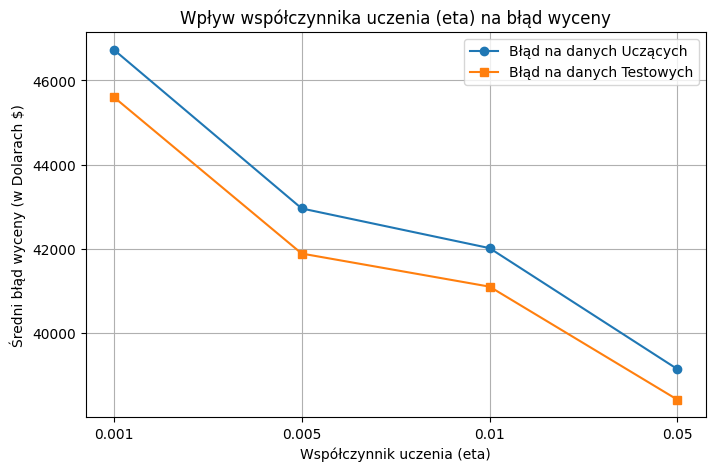


ROZPOCZYNAM TESTY PARAMETRU: Batch_Size

>> Badana wartość [Batch_Size]: 1
   Próba 1/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $35,824
   Próba 2/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $37,339
   Próba 3/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zako

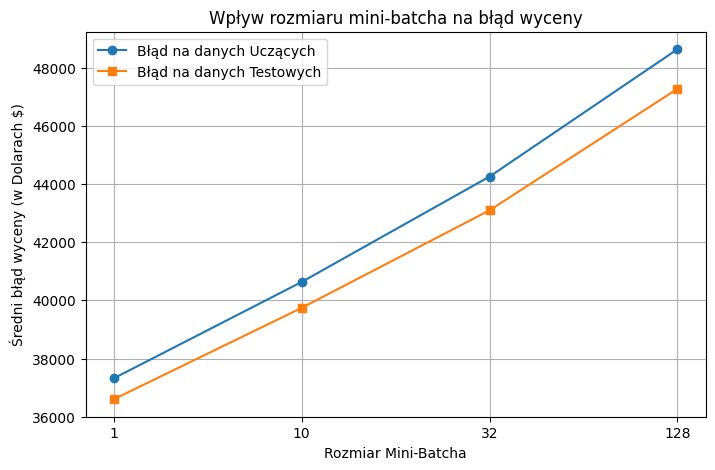


ROZPOCZYNAM TESTY PARAMETRU: Epochs

>> Badana wartość [Epochs]: 5
   Próba 1/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Błąd testowy: $43,879
   Próba 2/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Błąd testowy: $43,757
   Próba 3/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Błąd testowy: $43,510

>> Badana wartość [Epochs]: 10
   Próba 1/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Błąd testowy: $42,360
   Próba 2/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Błąd testowy: $42,157
   Próba 3/3... Epoka 1 zakończona
Epoka 2 

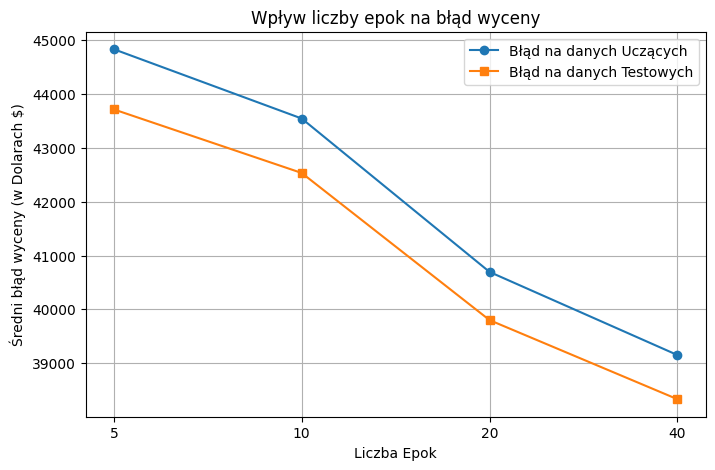


ROZPOCZYNAM TESTY PARAMETRU: Hidden_Neurons

>> Badana wartość [Hidden_Neurons]: 5
   Próba 1/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $39,966
   Próba 2/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $40,080
   Próba 3/3... Epoka 1 zakończona
Epoka 2 zakończona
Epok

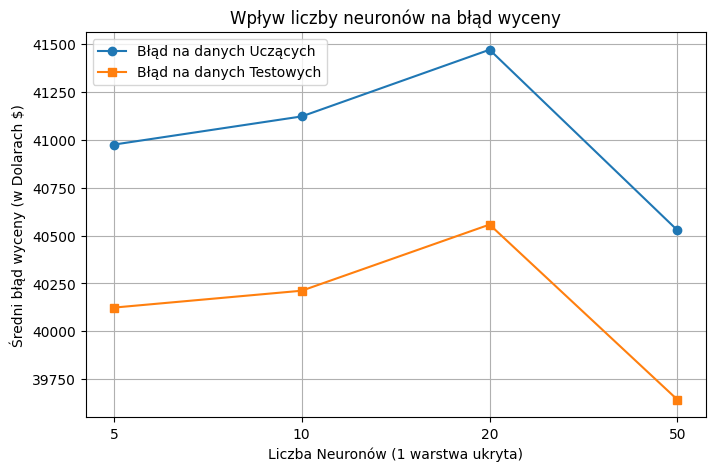


ROZPOCZYNAM TESTY PARAMETRU: Network_Layers

>> Badana wartość [Network_Layers]: [12, 10, 1]
   Próba 1/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $40,934
   Próba 2/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $40,513
   Próba 3/3... Epoka 1 zakończona
Epoka 2 zakoń

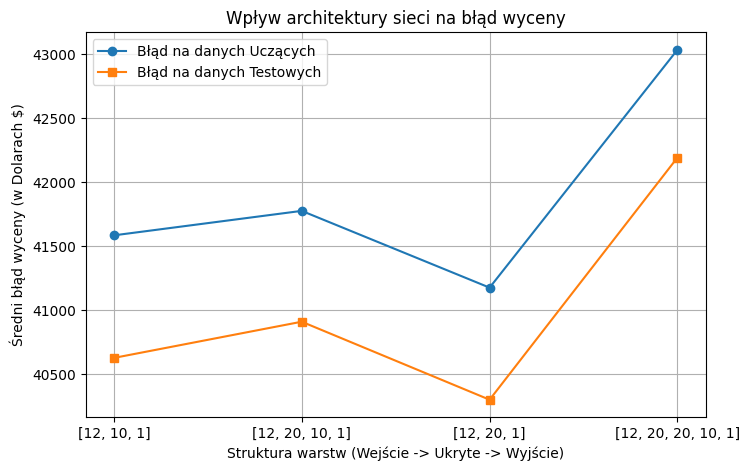


ROZPOCZYNAM TESTY PARAMETRU: Network_Shapes

>> Badana wartość [Network_Shapes]: [12, 40, 1]
   Próba 1/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $39,533
   Próba 2/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $40,275
   Próba 3/3... Epoka 1 zakończona
Epoka 2 zakoń

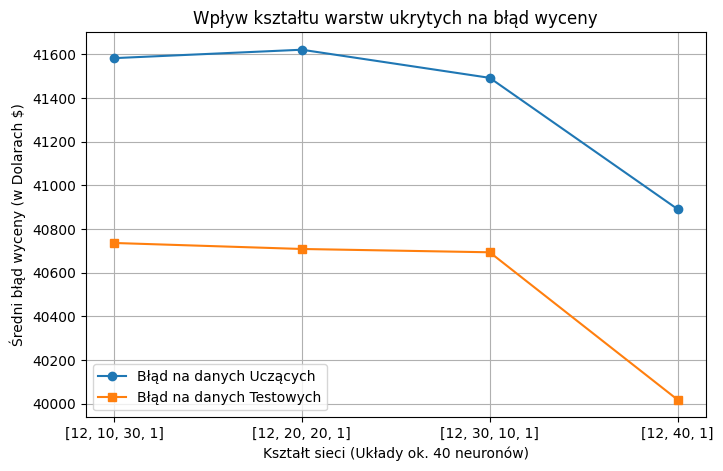


ROZPOCZYNAM TESTY PARAMETRU: Train_Size

>> Badana wartość [Train_Size]: 1000
   Próba 1/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $45,314
   Próba 2/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $47,545
   Próba 3/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 z

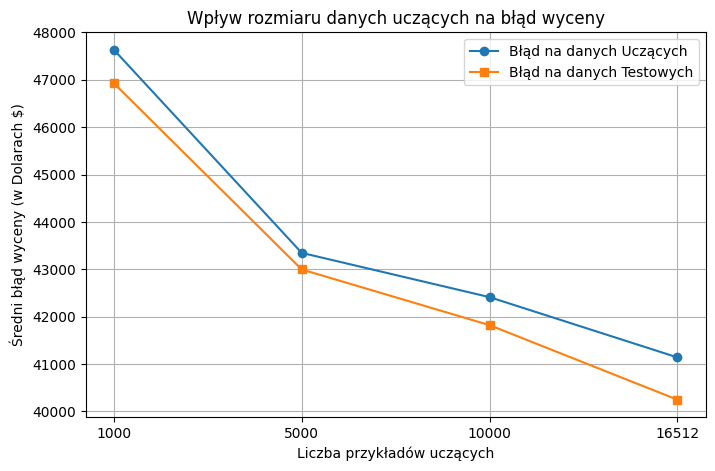


ROZPOCZYNAM TESTY PARAMETRU: Test_Size

>> Badana wartość [Test_Size]: 500
   Próba 1/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $40,218
   Próba 2/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zakończona
Epoka 4 zakończona
Epoka 5 zakończona
Epoka 6 zakończona
Epoka 7 zakończona
Epoka 8 zakończona
Epoka 9 zakończona
Epoka 10 zakończona
Epoka 11 zakończona
Epoka 12 zakończona
Epoka 13 zakończona
Epoka 14 zakończona
Epoka 15 zakończona
Epoka 16 zakończona
Epoka 17 zakończona
Epoka 18 zakończona
Epoka 19 zakończona
Epoka 20 zakończona
Błąd testowy: $39,139
   Próba 3/3... Epoka 1 zakończona
Epoka 2 zakończona
Epoka 3 zako

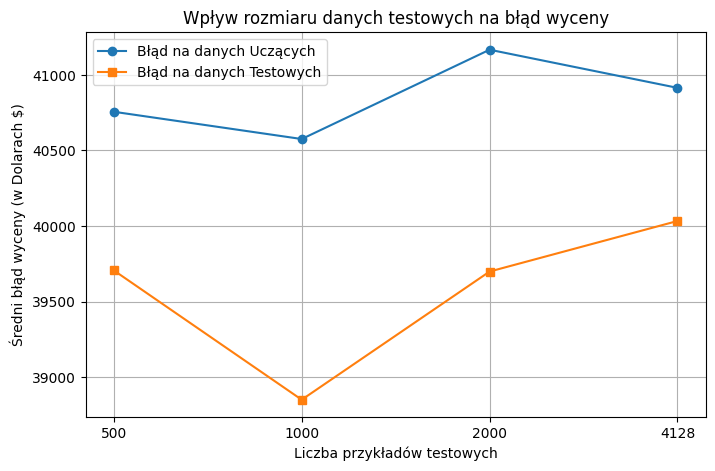

In [ ]:

# ==========================================
# 1. GŁÓWNA FUNKCJA TESTUJĄCA (AUTOMAT)
# ==========================================
def run_regression_experiment(param_name, values_to_test, param_type='eta'):
    results = []
    runs_per_config = 3 # Zgodnie z wytycznymi - powtarzamy uczenie 3 razy i wyciągniemy średnią
    
    # Nasze parametry bazowe (kontrolne) - sieć wraca do nich przy każdym nowym teście
    base_sizes = [12, 20, 1]
    base_epochs = 20
    base_batch = 10
    base_eta = 0.01
    
    print(f"\n{'='*50}\nROZPOCZYNAM TESTY PARAMETRU: {param_name}\n{'='*50}")
    
    with open('regression_results.csv', mode='a', newline='') as file:
        writer = csv.writer(file)
        
        for val in values_to_test:
            print(f"\n>> Badana wartość [{param_name}]: {val}")
            for run in range(runs_per_config):
                print(f"   Próba {run+1}/{runs_per_config}...", end=" ")
                
                # Resetujemy parametry do bazy
                current_eta = base_eta
                current_batch = base_batch
                current_epochs = base_epochs
                current_sizes = base_sizes
                current_train = training_data
                current_test = test_data
                
                # NADPISUJEMY tylko ten jeden parametr, który aktualnie badamy
                if param_type == 'eta': current_eta = val
                elif param_type == 'batch': current_batch = val
                elif param_type == 'epochs': current_epochs = val
                elif param_type == 'neurons': current_sizes = [12, val, 1]
                elif param_type == 'layers': current_sizes = val
                elif param_type == 'train_size': current_train = training_data[:val]
                elif param_type == 'test_size': current_test = test_data[:val]
                
                # Tworzymy świeżą sieć z odpowiednimi warstwami
                net = RegressionNetwork(current_sizes)
                
                # Uczymy sieć (test_data=None, żeby nie spamowało konsoli w trakcie testów)
                net.SGD(current_train, epochs=current_epochs, mini_batch_size=current_batch, eta=current_eta)
                
                # Obliczamy końcowy błąd (MAE) dla zbioru uczącego i testowego
                _, train_mae = net.evaluate(current_train)
                _, test_mae = net.evaluate(current_test)
                
                # Mnożymy przez 100 000, żeby mieć wynik w prawdziwych dolarach
                final_train_error = train_mae * 100000
                final_test_error = test_mae * 100000
                
                print(f"Błąd testowy: ${final_test_error:,.0f}")
                
                # Zapisujemy do listy i do pliku
                results.append({'Value': str(val), 'Run': run+1, 'Train_Error': final_train_error, 'Test_Error': final_test_error})
                writer.writerow([param_name, str(val), run+1, final_train_error, final_test_error])
                file.flush()
                
    return pd.DataFrame(results)


# ==========================================
# 2. FUNKCJA RYSUJĄCA WYKRESY
# ==========================================
def plot_results(df, title, xlabel):
    # Grupujemy po badanej wartości i wyciągamy średnią z 3 prób
    avg_results = df.groupby('Value')[['Train_Error', 'Test_Error']].mean().reset_index()
    
    # Sortujemy wartości, żeby wykres się nie "plątał" (ważne przy liczbach)
    try:
        avg_results['Value_Num'] = pd.to_numeric(avg_results['Value'])
        avg_results = avg_results.sort_values('Value_Num')
        x_col = 'Value_Num'
    except:
        x_col = 'Value' 
        
    plt.figure(figsize=(8, 5))
    plt.plot(avg_results[x_col].astype(str), avg_results['Train_Error'], marker='o', label='Błąd na danych Uczących')
    plt.plot(avg_results[x_col].astype(str), avg_results['Test_Error'], marker='s', label='Błąd na danych Testowych')
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Średni błąd wyceny (w Dolarach $)')
    plt.legend()
    plt.grid(True)
    plt.show()


# ==========================================
# 3. URUCHOMIENIE 8 TESTÓW 
# ==========================================

# Parametr 1: Współczynnik uczenia (eta)
df_eta = run_regression_experiment('Learning_Rate', [0.001, 0.005, 0.01, 0.05], param_type='eta')
plot_results(df_eta, 'Wpływ współczynnika uczenia (eta) na błąd wyceny', 'Współczynnik uczenia (eta)')

# Parametr 2: Rozmiar Mini-Batcha
df_batch = run_regression_experiment('Batch_Size', [1, 10, 32, 128], param_type='batch')
plot_results(df_batch, 'Wpływ rozmiaru mini-batcha na błąd wyceny', 'Rozmiar Mini-Batcha')

# Parametr 3: Liczba epok
df_epochs = run_regression_experiment('Epochs', [5, 10, 20, 40], param_type='epochs')
plot_results(df_epochs, 'Wpływ liczby epok na błąd wyceny', 'Liczba Epok')

# Parametr 4: Liczba neuronów w warstwie ukrytej
df_neurons = run_regression_experiment('Hidden_Neurons', [5, 10, 20, 50], param_type='neurons')
plot_results(df_neurons, 'Wpływ liczby neuronów na błąd wyceny', 'Liczba Neuronów (1 warstwa ukryta)')

# Parametr 5: Architektura sieci (Liczba warstw)
layer_configs = [[12, 10, 1], [12, 20, 1], [12, 20, 10, 1], [12, 20, 20, 10, 1]]
df_layers = run_regression_experiment('Network_Layers', layer_configs, param_type='layers')
plot_results(df_layers, 'Wpływ architektury sieci na błąd wyceny', 'Struktura warstw (Wejście -> Ukryte -> Wyjście)')

# Parametr 6: Kształt warstw (Tyle samo neuronów, różny układ)
shape_configs = [[12, 40, 1], [12, 20, 20, 1], [12, 30, 10, 1], [12, 10, 30, 1]]
df_shapes = run_regression_experiment('Network_Shapes', shape_configs, param_type='layers')
plot_results(df_shapes, 'Wpływ kształtu warstw ukrytych na błąd wyceny', 'Kształt sieci (Układy ok. 40 neuronów)')

# Parametr 7: Rozmiar zbioru uczącego
df_train = run_regression_experiment('Train_Size', [1000, 5000, 10000, 16512], param_type='train_size')
plot_results(df_train, 'Wpływ rozmiaru danych uczących na błąd wyceny', 'Liczba przykładów uczących')

# Parametr 8: Rozmiar zbioru testowego
df_test = run_regression_experiment('Test_Size', [500, 1000, 2000, 4128], param_type='test_size')
plot_results(df_test, 'Wpływ rozmiaru danych testowych na błąd wyceny', 'Liczba przykładów testowych')

## 6. Results & Discussion

The implementation of a custom-built Neural Network provides a unique opportunity to directly observe how foundational hyperparameters impact mathematical regression models. Our automated 8-parameter optimization suite yielded the following key insights:

### Learning Dynamics
* **Learning Rate ($\eta$):** The data demonstrates a strong inverse relationship between the learning rate and the final error. The lowest MAE (~\$37,000) was achieved at the highest tested rate ($\eta = 0.05$). Lower values (0.001) caused the gradient descent to converge too slowly within the 20-epoch limit, leading to significant underfitting.
* **Mini-Batch Size:** The results heavily favor smaller batch sizes. A batch size of 1 (Stochastic Gradient Descent) forced continuous, immediate weight updates, resulting in the lowest error. Conversely, a batch size of 128 updated the weights too infrequently, causing the error to spike to nearly $48,000.
* **Epochs:** As expected, extending the training duration from 5 to 40 epochs steadily decreased both training and testing errors. Notably, the testing error continued to drop alongside the training error, indicating that the model successfully generalized the housing market rules without falling into the trap of overfitting.

### Network Architecture
* **Hidden Neurons & Layers:** Our architectural tests revealed a fascinating property of this specific regression problem: **complexity does not equal accuracy.** Increasing the number of hidden neurons from 5 to 50 within a single layer produced negligible improvements. Furthermore, creating "deep" network architectures with 3 or 4 hidden layers (e.g., `[12, 20, 20, 10, 1]`) actually deteriorated performance. 
* **Conclusion on Shape:** The lowest error margins were consistently achieved by simple, shallow architectures (such as `[12, 20, 1]` or `[12, 40, 1]`). This proves that tabular regression problems like real estate valuation do not require extreme depth, unlike image or text processing tasks.

### Data Dependency
* **Training Data Size:** The experiment highlights the fundamental rule of machine learning: data volume drives accuracy. When restricted to learning from just 1,000 neighborhoods, the network struggled significantly. Exposing it to the full dataset (16,512 neighborhoods) dropped the error by over $6,000.

### Final Conclusion
Despite the strict constraint of utilizing raw Python and basic Linear Algebra matrices without the aid of optimized deep-learning libraries, the custom neural network performed exceptionally well. The optimized architecture achieved a testing MAE in the range of **$36,000 - $38,000**. 
